In [2]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.manifold import TSNE

DISTINCT_COLORS = [
    "#E6194B",  
    "#3CB44B", 
    "#4363D8", 
    "#F58231",  
    "#911EB4",  
]
SEED = 42

In [3]:
original_data   = np.load('../duomenys/original_data.npy')
labels          = np.load('../duomenys/ship-types.npy')
distance_matrix = np.load('../duomenys/dist_mat.npy')

In [4]:
unique_labels, labels_encoded = np.unique(labels, return_inverse=True)
label_names = {i: name for i, name in enumerate(unique_labels)}

n_samples = original_data.shape[0]
original_flat = original_data.reshape(n_samples, -1)

all_classes = np.unique(labels_encoded)
class_colors = {cls: DISTINCT_COLORS[i % len(DISTINCT_COLORS)]
                for i, cls in enumerate(all_classes)}

embedding = TSNE(
    perplexity=5,
    early_exaggeration=24,
    learning_rate=10,
    max_iter=500,
    n_components=2,
    random_state=SEED
).fit_transform(distance_matrix)

In [5]:
from sklearn.model_selection import train_test_split

original_flat = original_data.reshape((-1, original_data.shape[1]*original_data.shape[2]))
X_train, X_test, y_train, y_test, emb_train, emb_test = train_test_split(
    original_flat, labels_encoded, embedding, test_size=0.3, random_state=SEED, stratify=labels_encoded
)

In [6]:
import pandas as pd

In [7]:
from sklearn.metrics import confusion_matrix

In [8]:
def run_random_forest(X_train, X_test, y_train, y_test, label_names, **params):

    rf = RandomForestClassifier(**params)
    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    print(f"\n{'='*60}")
    for param, v in params.items():
        print(f"{param} : {v}")
    print(f"{'='*60}")
    print("Klasifikavimo lentele (true/pred)")
    cm_df = pd.DataFrame(cm)
    print(cm_df.to_string())

    n       = cm.sum()
    diag    = np.diag(cm)
    rowsums = cm.sum(axis=1)
    colsums = cm.sum(axis=0)

    precision = np.where(colsums > 0, diag / colsums, 0.0)
    recall    = np.where(rowsums > 0, diag / rowsums, 0.0)
    f1        = np.where((precision + recall) > 0,
                         2 * precision * recall / (precision + recall), 0.0)
    accuracy  = diag.sum() / n

    print("\nMetrikos kiekvienai klasei:")
    print(pd.DataFrame({"precision": precision, "recall": recall, "f1": f1},
                       index=[label_names[c] for c in range(5)]).round(4).to_string())
    print(f"\nAccuracy      : {accuracy:.4f}")
    print(f"Macro precision : {precision.mean():.4f}")
    print(f"Macro recall    : {recall.mean():.4f}")
    print(f"Macro F1        : {f1.mean():.4f}")

    return rf

In [9]:
rf_orig = run_random_forest(X_train, X_test, y_train, y_test, label_names)


Klasifikavimo lentele (true/pred)
    0   1   2   3   4
0  36   2   0   1   6
1   6  36   0   0   3
2   2   0  43   0   0
3   0   1   2  40   2
4   6   2   0   0  37

Metrikos kiekvienai klasei:
           precision  recall      f1
Cargo         0.7200  0.8000  0.7579
Fishing       0.8780  0.8000  0.8372
Passenger     0.9556  0.9556  0.9556
Pilot         0.9756  0.8889  0.9302
Tanker        0.7708  0.8222  0.7957

Accuracy      : 0.8533
Macro precision : 0.8600
Macro recall    : 0.8533
Macro F1        : 0.8553


In [10]:
X_train_tsne, X_test_tsne, y_train_tsne, y_test_tsne = train_test_split(
    embedding, labels_encoded, test_size=0.3, random_state=SEED, stratify=labels_encoded
)

In [11]:
rf_proj = run_random_forest(X_train_tsne, X_test_tsne, y_train_tsne, y_test_tsne, label_names)


Klasifikavimo lentele (true/pred)
    0   1   2   3   4
0  25   5   4   1  10
1   6  34   1   0   4
2   3   0  37   3   2
3   0   0   3  39   3
4   6   3   4   0  32

Metrikos kiekvienai klasei:
           precision  recall      f1
Cargo         0.6250  0.5556  0.5882
Fishing       0.8095  0.7556  0.7816
Passenger     0.7551  0.8222  0.7872
Pilot         0.9070  0.8667  0.8864
Tanker        0.6275  0.7111  0.6667

Accuracy      : 0.7422
Macro precision : 0.7448
Macro recall    : 0.7422
Macro F1        : 0.7420


In [12]:
import matplotlib.colors as mcolors

In [13]:
def plot_decision_boundary(
    clf, 
    X_test_sc,
    y_test,
    label_names,
    title,
    ax,
    unique_classes,
    step=0.3
):

    x_min = X_test_sc[:,0].min() - 1
    x_max = X_test_sc[:,0].max() + 1
    y_min = X_test_sc[:,1].min() - 1
    y_max = X_test_sc[:,1].max() + 1

    xx, yy = np.meshgrid(np.arange(x_min, x_max, step),
                         np.arange(y_min, y_max, step))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])

    class_to_idx = {c: i for i, c in enumerate(unique_classes)}
    Z_idx = np.array([class_to_idx[z] for z in Z]).reshape(xx.shape)
    n_classes = len(unique_classes)
    bg_cmap = mcolors.ListedColormap([class_colors[c] for c in unique_classes])
    ax.contourf(xx, yy, Z_idx, alpha=0.25, cmap=bg_cmap,
                levels=np.arange(-0.5, n_classes, 1))

    # Mokymo taškai
    for cls in unique_classes:
        mask = y_test == cls
        ax.scatter(X_test_sc[mask, 0], X_test_sc[mask, 1],
                   c=class_colors[cls], edgecolors='k', s=60,
                   label=label_names[cls], zorder=3)

    ax.set_title(title, fontsize=11)
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.legend(fontsize=7, loc="best")




In [14]:
import matplotlib.pyplot as plt

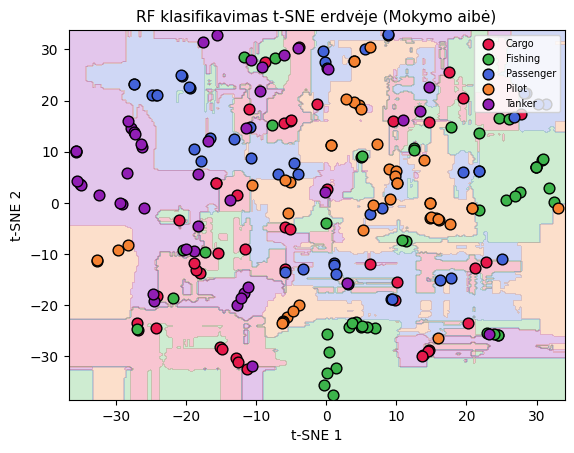

In [15]:
fig, ax = plt.subplots()

plot_decision_boundary(
    rf_proj, X_test_tsne, y_test_tsne, label_names, unique_classes=all_classes,
    title="RF klasifikavimas t-SNE erdvėje (Mokymo aibė)",
    ax=ax
)

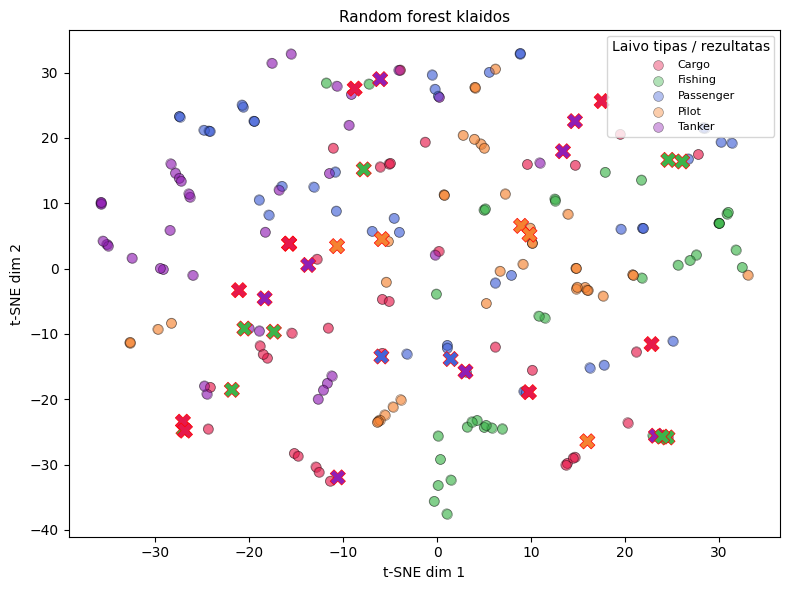

In [16]:
fig2, ax2 = plt.subplots(figsize=(8, 6))

unique_cls = np.unique(labels_encoded)
y_pred = rf_orig.predict(X_test)
correct = y_pred == y_test 

# Teisingai klasifikuoti — permatomi (alpha=0.4)
ax2.scatter(emb_test[correct, 0], emb_test[correct, 1],
            c=[class_colors[c] for c in y_test[correct]],
            s=50, edgecolors='k', linewidths=0.5, marker='o', alpha=0.4, zorder=2)

for cls in unique_cls:
    mask = correct & (y_test == cls)
    ax2.scatter(
        emb_test[mask, 0], emb_test[mask, 1],
        c=class_colors[cls], s=50, edgecolors='k', linewidths=0.5,
        marker='o', alpha=0.4, zorder=2,
        label=unique_labels[cls]
    )

# Klaidingai klasifikuoti — ryškūs ir didesni (alpha=1.0, s=120)
ax2.scatter(
    emb_test[~correct, 0], emb_test[~correct, 1],
    c=[class_colors[c] for c in y_test[~correct]],
    s=120, edgecolors='red', linewidths=0.5, marker='X', alpha=1.0, zorder=3
)
ax2.legend(fontsize=8, loc='upper right', title="Laivo tipas / rezultatas")

ax2.set_title("Random forest klaidos", fontsize=11)
ax2.set_xlabel("t-SNE dim 1")
ax2.set_ylabel("t-SNE dim 2")
plt.tight_layout()
# plt.savefig('./plots/rf_errors_orig.svg', format='svg')
plt.show()


In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import pandas as pd

param_grid = {
    'n_estimators': [20, 75, 100, 200],
    'max_depth':    [None, 8, 32, 64],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
)

grid_search.fit(X_train, y_train)

# ── Results ───────────────────────────────────────────────────────────────────
print(f"Best params:  {grid_search.best_params_}")
print(f"Best CV acc:  {grid_search.best_score_:.4f}")

# Full results as a sorted DataFrame
results_df = pd.DataFrame(grid_search.cv_results_)
cols = ['param_n_estimators', 'param_max_depth',
        'mean_train_score', 'mean_test_score', 'std_test_score', 'rank_test_score']
print(results_df[cols].sort_values('rank_test_score').to_string(index=False))

# ── Best model ready to use ───────────────────────────────────────────────────
rf_best = grid_search.best_estimator_

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best params:  {'max_depth': None, 'n_estimators': 100}
Best CV acc:  0.8133
 param_n_estimators param_max_depth  mean_train_score  mean_test_score  std_test_score  rank_test_score
                100            None          1.000000         0.813333        0.045316                1
                100              32          1.000000         0.813333        0.045316                1
                100              64          1.000000         0.813333        0.045316                1
                 75            None          1.000000         0.807619        0.046423                4
                 75              32          1.000000         0.807619        0.046423                4
                 75              64          1.000000         0.807619        0.046423                4
                 20               8          0.927143         0.807619        0.051955                4
                200            

In [18]:
est = rf_orig.estimators_
depths = [estimator.tree_.max_depth for estimator in est]

max(depths)

24

> Geriausias hiperparametrų rinkinys - 75 estimatoriai ir neribotas medžio gylis (didžiausias gautas gylis - 24)

In [19]:
rf_optim = run_random_forest(X_train, X_test, y_train, y_test, label_names,
                            **grid_search.best_params_)


max_depth : None
n_estimators : 100
Klasifikavimo lentele (true/pred)
    0   1   2   3   4
0  37   2   1   1   4
1   6  35   0   1   3
2   2   0  42   0   1
3   0   2   2  40   1
4   5   2   0   0  38

Metrikos kiekvienai klasei:
           precision  recall      f1
Cargo         0.7400  0.8222  0.7789
Fishing       0.8537  0.7778  0.8140
Passenger     0.9333  0.9333  0.9333
Pilot         0.9524  0.8889  0.9195
Tanker        0.8085  0.8444  0.8261

Accuracy      : 0.8533
Macro precision : 0.8576
Macro recall    : 0.8533
Macro F1        : 0.8544


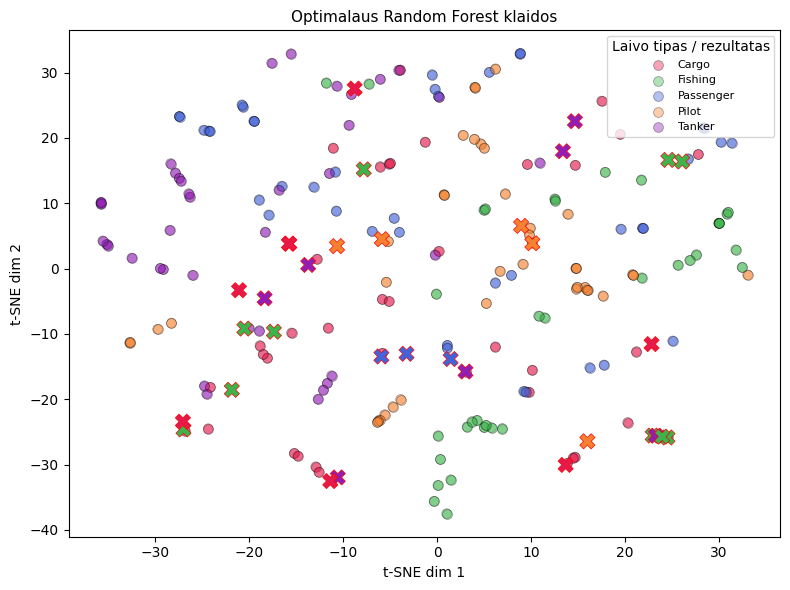

In [20]:
fig2, ax2 = plt.subplots(figsize=(8, 6))

unique_cls = np.unique(labels_encoded)
y_pred = rf_optim.predict(X_test)
correct = y_pred == y_test 

# Teisingai klasifikuoti — permatomi (alpha=0.4)
ax2.scatter(emb_test[correct, 0], emb_test[correct, 1],
            c=[class_colors[c] for c in y_test[correct]],
            s=50, edgecolors='k', linewidths=0.5, marker='o', alpha=0.4, zorder=2)

for cls in unique_cls:
    mask = correct & (y_test == cls)
    ax2.scatter(
        emb_test[mask, 0], emb_test[mask, 1],
        c=class_colors[cls], s=50, edgecolors='k', linewidths=0.5,
        marker='o', alpha=0.4, zorder=2,
        label=unique_labels[cls]
    )

# Klaidingai klasifikuoti — ryškūs ir didesni (alpha=1.0, s=120)
ax2.scatter(
    emb_test[~correct, 0], emb_test[~correct, 1],
    c=[class_colors[c] for c in y_test[~correct]],
    s=120, edgecolors='red', linewidths=0.5, marker='X', alpha=1.0, zorder=3
)
ax2.legend(fontsize=8, loc='upper right', title="Laivo tipas / rezultatas")

ax2.set_title("Optimalaus Random Forest klaidos", fontsize=11)
ax2.set_xlabel("t-SNE dim 1")
ax2.set_ylabel("t-SNE dim 2")
plt.tight_layout()
# plt.savefig('./plots/rf_errors_orig.svg', format='svg')
plt.show()


In [21]:
unique_cls = np.unique(labels_encoded)
y_pred = rf_optim.predict(X_test)
correct = y_pred == y_test 

class_data = {
    'correct': {},
    'incorrect': {}
}

for cls in unique_cls:
    class_data['correct'][cls] = np.mean(X_test\
        .reshape((-1, 25, 10))\
        [correct & (y_test == cls)], axis=0
    ).mean(axis=0)

    class_data['incorrect'][cls] = np.mean(X_test\
        .reshape((-1, 25, 10))\
        [~correct & (y_test == cls)], axis=0
    ).mean(axis=0)

df = pd.DataFrame(
    {(status, label): values
     for status, classes in class_data.items()
     for label, values in classes.items()}
)

df['correct', 'feature_number'] = np.arange(df.shape[0])
df['incorrect', 'feature_number'] = np.arange(df.shape[0])

df_correct = df['correct'].melt(id_vars='feature_number', var_name='class', value_name='mean_value')
df_correct['status'] = 'correct'

df_incorrect = df['incorrect'].melt(id_vars='feature_number', var_name='class', value_name='mean_value')
df_incorrect['status'] = 'incorrect'

comparison_df = pd.concat([df_correct, df_incorrect], ignore_index=True)

In [22]:
pivot_df = comparison_df.pivot_table(
    index=['feature_number', 'class'],
    columns='status',
    values='mean_value'
).reset_index()

pivot_df.columns.name = None

pivot_df = pivot_df.rename(columns={
    'correct': 'mean_correct',
    'incorrect': 'mean_incorrect'
})

pivot_df['difference'] = pivot_df['mean_correct'] - pivot_df['mean_incorrect']
pivot_df['abs_difference'] = pivot_df['difference'].abs()

pivot_df = pivot_df.sort_values('abs_difference', ascending=False)

print(pivot_df.to_string(index=False))

 feature_number  class  mean_correct  mean_incorrect    difference  abs_difference
              1      4      0.679921        0.283352  3.965695e-01    3.965695e-01
              7      2      0.460887        0.849583 -3.886964e-01    3.886964e-01
              4      4      0.933256        0.569090  3.641654e-01    3.641654e-01
              3      3      0.104336        0.449911 -3.455742e-01    3.455742e-01
              6      4      0.882523        0.554631  3.278922e-01    3.278922e-01
              5      2      0.480304        0.746434 -2.661299e-01    2.661299e-01
              3      1      0.118738        0.369612 -2.508744e-01    2.508744e-01
              7      4      0.335777        0.570314 -2.345371e-01    2.345371e-01
              1      2      0.367204        0.172134  1.950707e-01    1.950707e-01
              3      2      0.455316        0.264890  1.904266e-01    1.904266e-01
              8      1      0.010384        0.192508 -1.821244e-01    1.821244e-01
    

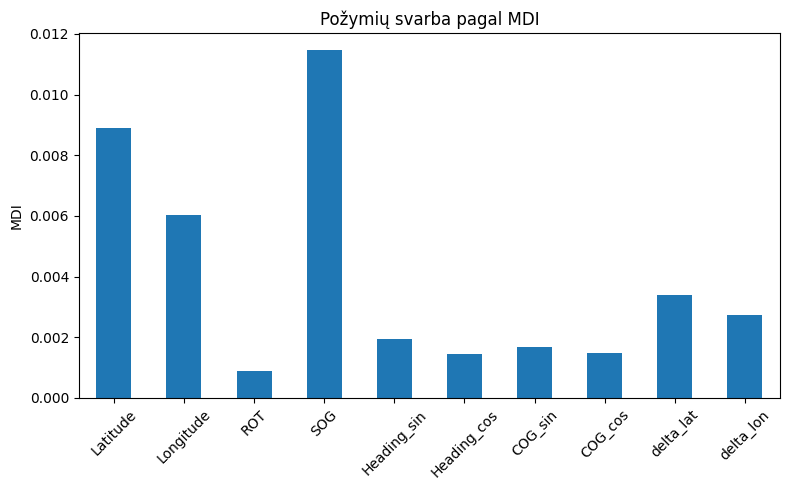

In [23]:
n_timesteps = original_data.shape[1]  # 25
n_features  = original_data.shape[2]  # 10
feature_names_short = [
    'Latitude', 'Longitude', 'ROT',
    'SOG', 'Heading_sin', 'Heading_cos',
    'COG_sin', 'COG_cos', 'delta_lat', 'delta_lon'
]

# (250,) -> (25, 10) 
imp_2d = rf_optim.feature_importances_.reshape(n_timesteps, n_features)
std_2d = np.std(
    [tree.feature_importances_.reshape(n_timesteps, n_features)
     for tree in rf_optim.estimators_], axis=0
)

importances_agg = imp_2d.mean(axis=0)   
# std_agg         = std_2d.mean(axis=0)   

forest_importances = pd.Series(importances_agg, index=feature_names_short)

fig, ax = plt.subplots(figsize=(8, 5))
forest_importances.plot.bar(yerr=0, ax=ax)
ax.set_title("Požymių svarba pagal MDI") # (aggregated over timesteps)
ax.set_ylabel("MDI")
ax.tick_params(axis='x', rotation=45)
fig.tight_layout()
plt.show()

SOG and Latitude are clearly the most important features for distinguishing ship types.
Longitude is moderately important.
ROT, Heading, COG, delta_lat, delta_lon contribute relatively little.
The large error bars on SOG and Latitude mean their importance varies a lot depending on which timestep — which is exactly what the heatmap explains.

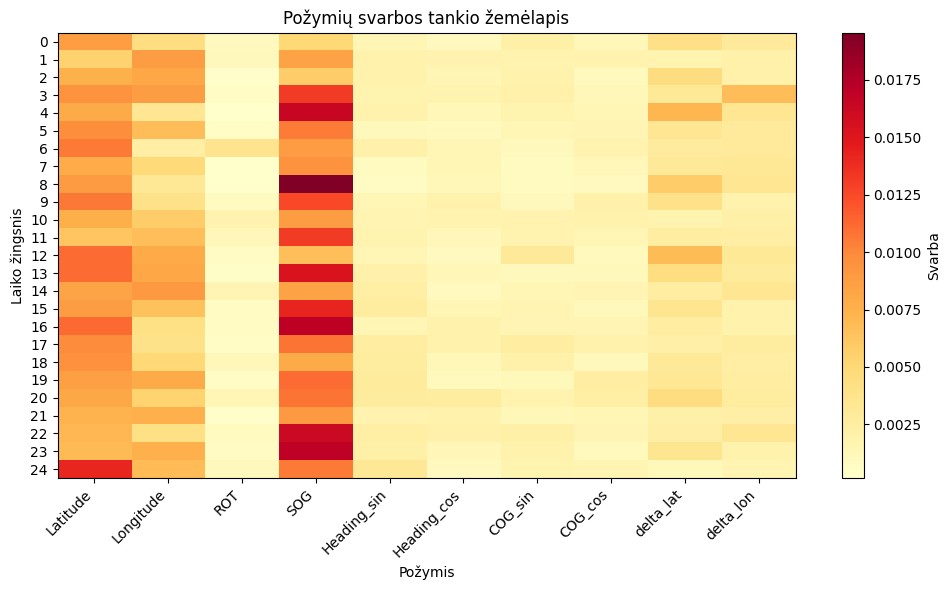

In [24]:
fig, ax = plt.subplots(figsize=(10, 6))

im = ax.imshow(imp_2d, aspect='auto', cmap='YlOrRd')

ax.set_xlabel("Požymis")
ax.set_ylabel("Laiko žingsnis")
ax.set_title("Požymių svarbos tankio žemėlapis")

ax.set_xticks(range(n_features))
ax.set_xticklabels(feature_names_short, rotation=45, ha="right")

ax.set_yticks(range(n_timesteps))

plt.colorbar(im, ax=ax, label="Svarba")

fig.tight_layout()
plt.show()

SOG is the single most discriminative feature, and critically it matters most at timesteps 9–13 and 20–24 (the middle and end of the trajectory window), not at the most recent observation.
Latitude is consistently important across almost all timesteps — ships of different types tend to operate in different geographic zones
Longitude  matters most at earlier timesteps (0–8), then fades.
Everything else (ROT, Heading, COG, deltas) is largely uniform and pale — low importance throughout.

The practical takeaway: ship type is primarily encoded in how fast the ship is moving (SOG) and where it is geographically (Latitude), not in its heading or rate of turn.

In [25]:
from sklearn.feature_selection import RFECV

In [34]:
rf_rfe_cv = RFECV(
    estimator=RandomForestClassifier(n_estimators=75, max_depth=None),
    min_features_to_select=50,
    step=25,
    n_jobs=-1,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
)


rf_rfe_cv.fit(
    X_train, y_train
)

,estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance either through a ``coef_``attribute or through a ``feature_importances_`` attribute.,RandomForestC...estimators=75)
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.Note that the last iteration may remove fewer than ``step`` features inorder to reach ``min_features_to_select``.",25
,"min_features_to_select min_features_to_select: int, default=1The minimum number of features to be selected. This number of featureswill always be scored, even if the difference between the originalfeature count and ``min_features_to_select`` isn't divisible by``step``... versionadded:: 0.20",50
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If theestimator is not a classifier or if ``y`` is neither binary nor multiclass,:class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value of None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"scoring scoring: str or callable, default=NoneScoring method to evaluate the :class:`RFE` selectors' performance. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: the `estimator`'s :ref:`default evaluation criterion ` is used.",None
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"n_jobs n_jobs: int or None, default=NoneNumber of cores to run in parallel while fitting across folds.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",-1
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance.For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case of:class:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",75
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None


In [ ]:
np.array([ [[1, 2], [3, 4]], [[5, 6], [7, 8]] ]).reshape((-1, 4))

array([[1, 2, 3, 4],
       [5, 6, 7, 8]])

In [ ]:
features = np.array([
    f'{feat}-{step}'
    for step in range(25)
    for feat in feature_names_short
])
features[rf_rfe_cv.support_]

array(['Latitude-0', 'Longitude-0', 'SOG-0', 'delta_lat-0', 'delta_lon-0',
       'Latitude-1', 'Longitude-1', 'SOG-1', 'Heading_sin-1',
       'Latitude-2', 'Longitude-2', 'SOG-2', 'delta_lat-2', 'Latitude-3',
       'Longitude-3', 'SOG-3', 'delta_lat-3', 'delta_lon-3', 'Latitude-4',
       'Longitude-4', 'SOG-4', 'delta_lat-4', 'Latitude-5', 'Longitude-5',
       'SOG-5', 'delta_lon-5', 'Latitude-6', 'SOG-6', 'delta_lon-6',
       'Latitude-7', 'Longitude-7', 'SOG-7', 'delta_lon-7', 'Latitude-8',
       'Longitude-8', 'SOG-8', 'delta_lat-8', 'Latitude-9', 'Longitude-9',
       'SOG-9', 'delta_lat-9', 'Latitude-10', 'Longitude-10', 'SOG-10',
       'Latitude-11', 'Longitude-11', 'SOG-11', 'Heading_cos-11',
       'Latitude-12', 'Longitude-12', 'SOG-12', 'Latitude-13',
       'Longitude-13', 'SOG-13', 'delta_lat-13', 'Latitude-14',
       'Longitude-14', 'SOG-14', 'delta_lon-14', 'Latitude-15',
       'Longitude-15', 'SOG-15', 'delta_lat-15', 'Latitude-16', 'SOG-16',
       'Heading_co

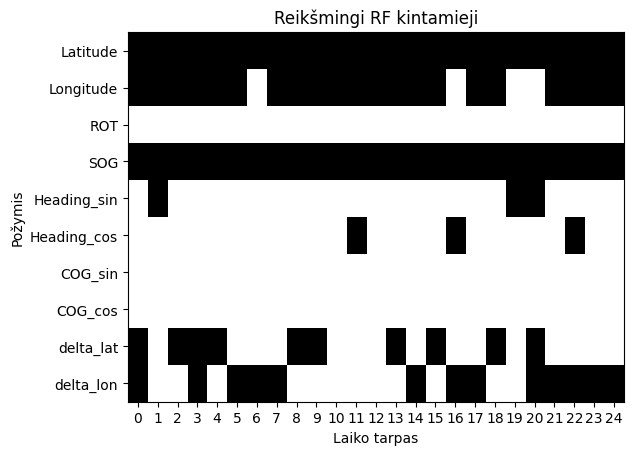

In [63]:
fig, ax = plt.subplots()

ax.imshow( 
    rf_rfe_cv.support_.reshape(25, 10).T,
    cmap='binary', aspect='auto'
)

ax.set_ylabel("Požymis")
ax.set_xlabel("Laiko tarpas")
ax.set_yticks(ticks=range(10), labels=feature_names_short)
ax.set_xticks(range(25))

ax.set_title('Reikšmingi RF kintamieji')

plt.show()